## Setup

### Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
from pathlib import Path
from sklearn.datasets import make_blobs

from ipywidgets import interact, IntSlider
import copy

### Utility Functions

In [22]:
import torch.optim as optim

def do_linear_regression_interactive(model, x, y_obs, optimizer_class=optim.RMSprop, lr=0.1, nepochs=100):
    

    # store initial model state to reset before training
    initial_state = copy.deepcopy(model.state_dict())

    def train_and_plot(step_to_show):
        # reset model to initial state
        model.load_state_dict(copy.deepcopy(initial_state))
        optimizer = optimizer_class(model.parameters(), lr=lr)

        # train up to the selected step
        for step in range(step_to_show + 1):
            optimizer.zero_grad()
            y_pred = model(x)
            loss = (y_pred - y_obs).square().mean()
            loss.backward()
            optimizer.step()

        # plot the data and model at this step
        with torch.no_grad():
            y_pred = model(x)
            loss = (y_pred - y_obs).square().mean()

        plt.figure()
        plt.title(f"Data and Model\nstep={step_to_show}, loss={loss:.4f}")
        plt.plot(x, y_obs, "o", color="black")
        plt.plot(x, model.weight.item()*x + model.bias.item(), color="r", label="Model")
        plt.legend()
        plt.show()

    # create slider with steps of 5
    step_slider = IntSlider(min=0, max=nepochs, step=5, value=0, description='Epoch:')
    interact(train_and_plot, step_to_show=step_slider)

def do_binary_classification_interactive(model, X, labels, nepochs=40, step_size = 1, optimizer_class = optim.RMSprop):
    """Interactive binary classification with epoch slider"""

    loss_function=nn.BCEWithLogitsLoss()

    # store initial model state to reset before training
    initial_state = copy.deepcopy(model.state_dict())

    def train_and_plot(epoch_to_show):
        # reset model to initial state
        model.load_state_dict(copy.deepcopy(initial_state))
        optimizer = optimizer_class(model.parameters(), lr=0.1)

        # Train up to the selected epoch
        for epoch in range(epoch_to_show + 1):
            optimizer.zero_grad()
            y_pred = model(X)
            loss = loss_function(y_pred.squeeze(), labels.float())
            loss.backward()
            optimizer.step()

        # Plot the result at this epoch
        with torch.no_grad():
            y_pred = model(X)
            probs = torch.sigmoid(y_pred)

        plt.figure(figsize=(6, 5))
        plt.title(f"epoch={epoch_to_show}, loss={loss.item():.4f}")
        plt.scatter(*X.T, s=20, c=(probs > 0.5).squeeze(), cmap='Set1')
        plt.show()

    # Create slider
    epoch_slider = IntSlider(min=0, max=nepochs, step=step_size, value=0, description='Epoch:')
    interact(train_and_plot, epoch_to_show=epoch_slider)

class utils:
    do_linear_regression_interactive = do_linear_regression_interactive
    do_binary_classification_interactive = do_binary_classification_interactive


## Section 1: Linear Models Can Identify Linear Decision Boundaries in Classification

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer of nodes (neurons) that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `utils.do_binary_classification(model, features, labels)` | Do binary classification. `features` is the input data and `labels` are the true class labels from the data. |
| `y_pred = model(X_input)` | Pass input `X_input` to a neuronal network `model` and assign the output to a variable `y_pred`. |
| `(y_pred-y_obs).square().mean()` | Calculate the mean squared error of the model prediction `y_pred` compared to the observed data `y_obs`. |
| `loss_function = nn.MSELoss()` | Creates a mean squared error (MSE) loss function and assigns it to a variable named `loss_function`. |
| `loss_function(y_pred, y_obs)` | Calculates the loss between the output of the network `y_pred` and the observed y-values from the data `y_obs`. |
| `loss_function(y_pred, y_obs).item()` | Extracts the loss value - i.e. the number alone as a ``float`` and not as a ``tensor``. |

## Section 1: Activation Functions Enables Neural Networks to Capture Non-Linear Relationships in Data

Often, the relationship you want to uncover in your data isn't linear. In this section, we'll see how to make neural network models that can capture non-linear patterns in the data.

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer of nodes (neurons) that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `nn.ReLU()` | Creates a rectified linear unit (ReLU) activation function.|
| `nn.Tanh()` | Creates hyperbolic tangent activation function.|
| `nn.Sigmoid()` | Creates a sigmoid activation function.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;` nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;` nn.Linear(10,1)`<br>`)` | Creates a container where layers and activation functions are stacked in a sequential order. This ensures that the input is passed through the network in that order.|
| `utils.do_binary_classification(model, X, labels)` | Do binary classification. `X` is the input data and `labels` are the true class labels for the data. |
| `utils.do_binary_classification(model, X, labels, epochs=200)` | Do binary classification and set the number of epochs to 200. |

Run cell below to generate data for linear binary classification

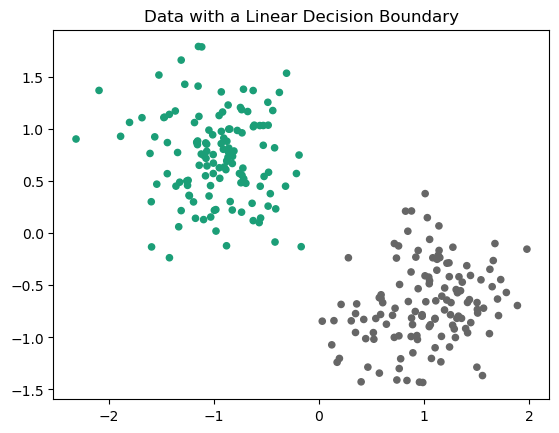

In [9]:
# generate two linearly separable clusters
features_linear, labels_linear = make_blobs(
    n_samples=256, 
    centers=[[-1, 0.7], [1, -0.7]],
    cluster_std=0.4,
    random_state=2026
)
features_linear = torch.tensor(features_linear, dtype=torch.float32)
labels_linear = torch.tensor(labels_linear, dtype=torch.long)

plt.scatter(*features_linear.T, s=20, c=labels_linear, cmap='Dark2');
plt.title('Data with a Linear Decision Boundary');

**Exercise**: Run the cell below to create a linear model with 2 input features and 1 output feature and pass this model as input to the function `utils.do_binary_classification_interactive`. Drag the slider to train the model. Is this model able to classify points in the two clusters correctly after training?

In [10]:
# create model
torch.manual_seed(2026)
model = nn.Linear(2,1)

utils.do_binary_classification_interactive(model, features_linear, labels_linear)

interactive(children=(IntSlider(value=0, description='Epoch:', max=40), Output()), _dom_classes=('widget-inter…

Run cell below to generate data for **non-linear** binary classification

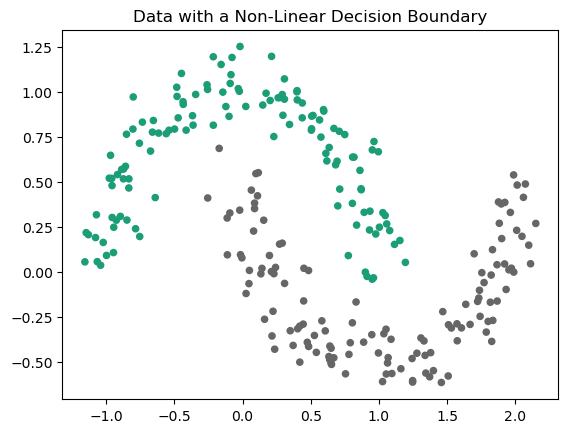

In [11]:
features_orig, labels_orig = make_moons(256, noise=0.1, random_state=42)
features = torch.tensor(features_orig, dtype=torch.float32)
labels = torch.tensor(labels_orig, dtype=torch.long)

plt.scatter(*features.T, s = 20, c = labels, cmap='Dark2')
plt.title('Data with a Non-Linear Decision Boundary');

**Exercise**: Create a linear model with 2 input features and 1 output feature. Pass this model as input to the function `utils.do_binary_classification`. Is this model able to classify points in the two clusters (mostly) correctly after training?

In [ ]:
# create model
torch.manual_seed(2026)
model = nn.Linear(2,1)

utils.do_binary_classification_interactive(model, features, labels)

interactive(children=(IntSlider(value=0, description='Epoch:', max=40), Output()), _dom_classes=('widget-inter…

**Exercise**: Use the same model to do binary classification but this time, try increasing the number of epochs (no need to go beyond 200). Is the model able to do the classification correctly now?

In [17]:
# create model
torch.manual_seed(2026)
model = nn.Linear(2,1)

utils.do_binary_classification_interactive(model, features, labels, nepochs=200)

interactive(children=(IntSlider(value=0, description='Epoch:', max=200), Output()), _dom_classes=('widget-inte…

Even if the result might have improved a little bit, the linear model isn't able to correctly classify all points, no matter how many epochs we train the model for. The reason for this is that the boundary separating the two classes of points is *non-linear*, and a linear model will never be able to capture a non-linear boundary. The models we have worked with until now will only be able to solve non-linear problems if we add non-linearity to the model. The non-linearity we add to our previous models is the so-called *activation function*. The activation function is what differentiates neural network models from simple linear transformations, and it's one of the key features that make neural networks so powerful. With activation functions, neural networks can, in principle, approximate any function, and thus, approximate any relationship - linear or non-linear - in a dataset.

**Demo**: Run the cell below to reate a model composed of two layers with a *rectified linear* unit between them and pass the model to the utility function `utils.do_binary_classification`. The first layer has two input features and one 16 output features, the last layer has 16 input features and 1 output feature. Is the model able to correctly classify all the points now?

In [25]:
torch.manual_seed(2026)
# create model
model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1)
)

utils.do_binary_classification_interactive(model, features, labels, nepochs=100)

interactive(children=(IntSlider(value=0, description='Epoch:'), Output()), _dom_classes=('widget-interact',))

There are different kinds of activation functions we can use in neural networks. Let's look at what some of the most common ones do to their input.

**Example**: Pass the tensor `x` provided below to a rectified linear unit (ReLU) activation function and assign the output to a variable named `out`. Then, run the cell with the code that plots the output against `x`. The plot shows to form of the ReLU function.

In [26]:
x = torch.linspace(-5,5,100)

In [27]:
out = nn.ReLU()(x)

Text(0.5, 1.0, ' ReLU\nActivation Function')

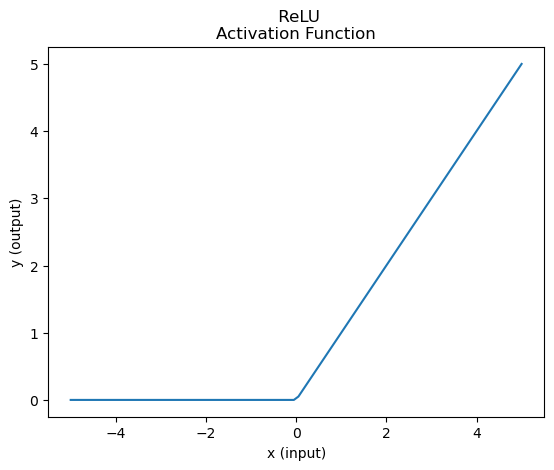

In [28]:
plt.plot(x,out)
plt.xlabel('x (input)')
plt.ylabel('y (output)')
plt.title(' ReLU\nActivation Function')

**Exercise**: Pass the tensor `x` provided below to a rectified linear unit (ReLU) activation function and assign the output to a variable named `out`. Then, run the cell with the code that plots the output against `x`. The plot shows to form of the hyperbolic tangent function.

In [29]:
x = torch.linspace(-5,5,100)

In [31]:
out = nn.Tanh()(x)

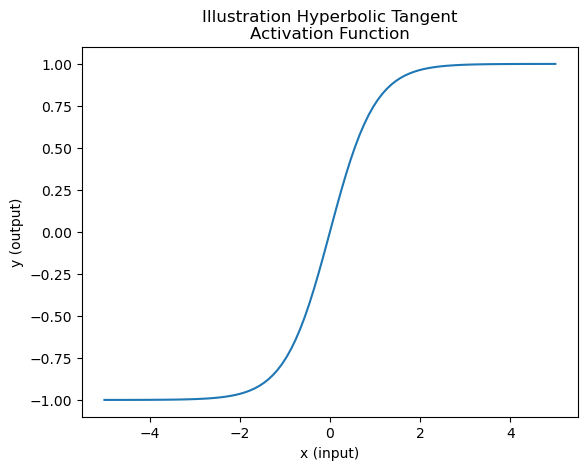

In [32]:
plt.plot(x, out)
plt.xlabel('x (input)')
plt.ylabel('y (output)')
plt.title('Illustration Hyperbolic Tangent\nActivation Function');

**Exercise**: Pass the tensor `x` containing random numbers to a hyperbolic tangent (tanh) activation function and assign the output to a variable named `out`. Then, run the cell with the code that plots this output against `x`. What effect does this activation function have on the input?

**Hint**: Look at the maximum and minimum value on the y-axis of the output relative to the input.

In [ ]:
torch.manual_seed(2025)
x = torch.randn(20)
x

tensor([-1.1607, -1.5591,  0.7782, -0.9990,  0.4670,  1.1802,  0.3709, -2.0193,
        -1.1871, -0.2822, -0.2651,  2.7671, -1.1414,  0.3533, -0.0972, -0.1674,
         0.9320, -0.7882, -2.8070,  0.5447])

In [ ]:
out = nn.Tanh()(x)

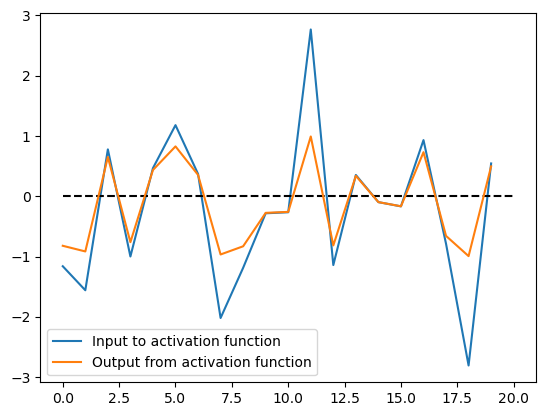

In [ ]:
plt.plot(x, label = 'Input to activation function')
plt.hlines(xmin=0, xmax=len(x), y=0, ls='--', colors='k')
plt.plot(out, label ='Output from activation function')
plt.legend();

**Exercise**: Pass the tensor `x` provided below to a sigmoid activation function and assign the output to a variable named `out`. Then, run the cell with the code that plots the output against `x`. The plot shows the form of the sigmoid function.

In [33]:
x = torch.linspace(-5,5,100)

In [34]:
out = nn.Sigmoid()(x)

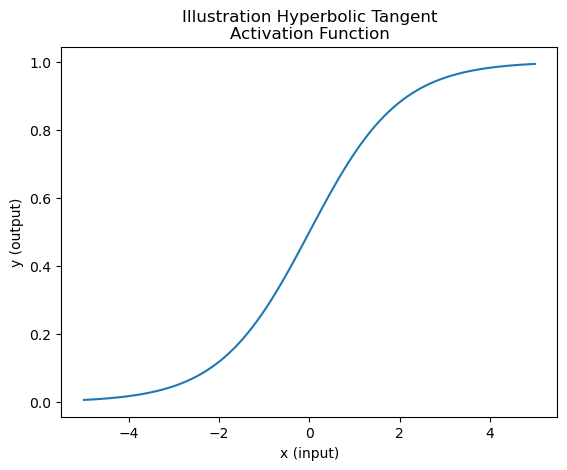

In [35]:
plt.plot(x, out)
plt.xlabel('x (input)')
plt.ylabel('y (output)')
plt.title('Illustration Hyperbolic Tangent\nActivation Function');

**Exercise**: Pass the tensor `x` containing random numbers to a hyperbolic tangent (tanh) activation function and assign the output to a variable named `out`. Then, run the cell with the code that plots this output against `x`. What effect does this activation function have on the input?

**Hint**: Look at the maximum and minimum value of the output on the y-axis.

In [36]:
torch.manual_seed(2025)
x = torch.randn(20)
x

tensor([-1.1607, -1.5591,  0.7782, -0.9990,  0.4670,  1.1802,  0.3709, -2.0193,
        -1.1871, -0.2822, -0.2651,  2.7671, -1.1414,  0.3533, -0.0972, -0.1674,
         0.9320, -0.7882, -2.8070,  0.5447])

In [37]:
out = nn.Sigmoid()(x)

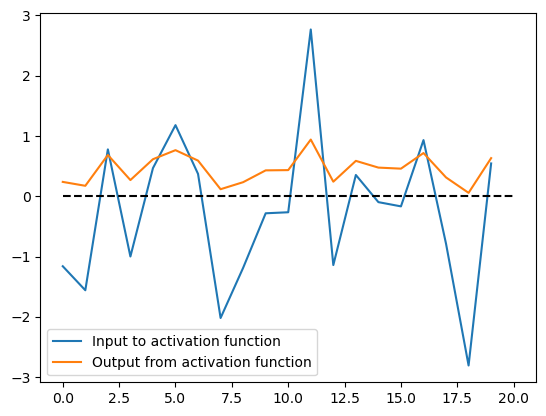

In [38]:
plt.plot(x, label = 'Input to activation function')
plt.hlines(xmin=0, xmax=len(x), y=0, ls='--', colors='k')
plt.plot(out, label ='Output from activation function')
plt.legend();

The hyperbolic tangent (Tanh) activation function was popular in early neural networks because it led to to faster convergence during training. However, it was later shown that the rectified linear unit (ReLU) often produced better results. Since then, ReLU has been the most commonly used activation function in between hidden layers in neural networks. But the Tanh activation function is still used in so-called recurrent neural networks, which you will encounter later in the course. Sigmoid activation functions are often used to convert the output at the end of a network to probabilities between 0 and 1, which is particularly relevant for binary classification problems.

## Section 2: Create Neural Network Models with Activation Functions

| Code | Description |
| :-- | :-- |
| `nn.Linear(n_features_in, n_features_out)` | Creates a linear model that takes in `n_features_in` input features (nodes) and outputs `n_features_out` features (nodes).|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(10,1)`<br>`)` | Creates a container where multiple layers are stacked in a sequential order. This ensures that input is passed through the network in that order during the forward pass.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(10,1)`<br>`)` | Creates a container with a ReLU activation function after the hidden layer, which has 10 nodes. |
| `model = nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(2,20),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(20,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Tanh(),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(10,1)`<br>`)` | Creates a model with a ReLU and a Tanh activation function after the first and second hidden layer, respectively. |

**Example**: Create the model illustrated below with 2 input features and 1 output feature and a sigmoid activation function after the output node.

In [46]:
nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid()
)

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

**Exercise**: Create the model illustrated below which has a ReLU activation function after the hidden layer. The model should have 2 input features, 4 nodes in the hidden layer and one output feature. Display the model.

In [45]:
nn.Sequential(
    nn.Linear(2,4),
    nn.ReLU(),
    nn.Linear(4,1)
)

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
)

**Exercise**: Create the model illustrated below, which has two hidden layers with a Tanh and ReLU activation function after the first and second one, respectively, and a sigmoid activation function after the output node. The model should have 2 input features and 1 output feature and the hidden layers should have 4 and 2 nodes, respectively. Display the model.

<img src="img/2x4x2x1_nn.jpg" width="400">

In [ ]:
model = nn.Sequential(
    nn.Linear(2,4),
    nn.Linear(4,2),
    nn.Linear(2,1)
)
model

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): Linear(in_features=4, out_features=2, bias=True)
  (2): Linear(in_features=2, out_features=1, bias=True)
)

**Exercise**: Create a linear model with 6 input features and 3 output features and no bias. Set the weights of the model to all ones. Then, pass the tensor `x` provided below to the model and inspect the output. What is the sum of the output values?

In [68]:
x = torch.linspace(0,5,6)

model = nn.Sequential(
    nn.Linear(6, 3, bias=False),
)
model[0].weight.data = torch.ones_like(model[0].weight.data)

x, model(x)

(tensor([0., 1., 2., 3., 4., 5.]),
 tensor([15., 15., 15.], grad_fn=<SqueezeBackward4>))

**Exercise**: Add a softmax activation function (use `nn.Softmax(dim=-1)`) after the linear layer in the model below. Pass the tensor `x` to the model and inspect the output. What is the sum of the output values now? What effect does the softmax activation function have on the output?

In [69]:
x = torch.linspace(0,5,6)

model = nn.Sequential(
    nn.Linear(6, 3, bias=False),
    nn.Softmax(dim=-1)
)
model[0].weight.data = torch.ones_like(model[0].weight.data)

x, model(x)

(tensor([0., 1., 2., 3., 4., 5.]),
 tensor([0.3333, 0.3333, 0.3333], grad_fn=<SoftmaxBackward0>))

## Section 3: Apply to neural data

| Code | Description |
| --- | --- |
| `nn.CrossEntropyLoss()` | Creates a cross-entropy loss function for multiclass classification problems.|
| `nn.BCELogitsWithLoss()` | Creates a cross-entropy loss function for binary classification problems.|


# Section 4 (or 3): Accuracy